In [18]:
import json
import pandas as pd

# 1. Abrir el archivo JSON original
with open('/content/TelecomX_Procesado (2).json', 'r') as f:
    datos_json = json.load(f)

# 2. Convertir la estructura anidada en una tabla plana (DataFrame)
df = pd.json_normalize(datos_json)

# 3. Verificamos que se cargó correctamente
print(f'Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas')
display(df.head())

Datos cargados: 7043 filas y 22 columnas


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,account.Charges.Daily
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40,2.796667


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df = pd.read_csv('/content/datos_churn_preparados.csv')

Limpieza: eliminación de columnas irrelevantes, encoding, normalización/ estandarización de datos

In [21]:
from sklearn.preprocessing import StandardScaler

#LIMPIEZA
df.columns = [col.split('.')[-1] for col in df.columns]

#ELIMINACION
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

#TRATAMIENTO DE GENDER
df['gender'] = df['gender'].astype(str).str.strip().str.capitalize()
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

#CORRECCIÓN DE TOTAL
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df.dropna(subset=['Total'], inplace=True)

#ONE-HOT ENCODING
cols_a_codificar = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=cols_a_codificar, dtype=int)

#ESCALAMIENTO
scaler = StandardScaler()
cols_a_escalar = ['tenure', 'Monthly', 'Total', 'Daily']
df[cols_a_escalar] = scaler.fit_transform(df[cols_a_escalar])

#VERIFICACIÓN FINAL
print("--- Verificación de Datos ---")
print(f"¿Hay nulos?: {df.isnull().sum().sum()}")
print(f"Forma del dataset: {df.shape}")
df.info()

--- Verificación de Datos ---
¿Hay nulos?: 0
Forma del dataset: (7043, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   int64  
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   float64
 6   PhoneService                             7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   Monthly                                  7043 non-null   float64
 9   Total                                    70

In [22]:
import warnings
warnings.filterwarnings('ignore')


Análisis de Equilibrio de Datos y Frecuencia de Abandono

--- Diagn3stico de Balance de Clases ---
Cantidades por grupo:
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribuci3n porcentual:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


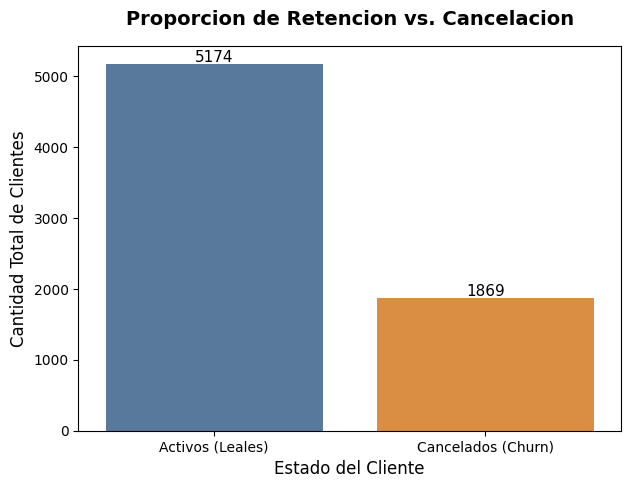

In [23]:
# OBTENER CONTEOS Y PORCENTAJES
conteo_churn = df['Churn'].value_counts()
proporcion_churn = df['Churn'].value_counts(normalize=True) * 100

# RESULTADOS EN CONSOLA
print("--- Diagn3stico de Balance de Clases ---")
print(f"Cantidades por grupo:\n{conteo_churn}")
print(f"\nDistribuci3n porcentual:\n{proporcion_churn}")

# GRAFICA
mi_paleta = ["#4E79A7", "#F28E2B"]
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df, palette=mi_paleta)

# TITULOS Y ETIQUETAS
plt.title('Proporcion de Retencion vs. Cancelacion', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad Total de Clientes', fontsize=12)

plt.xticks([0, 1], ['Activos (Leales)', 'Cancelados (Churn)'])

# NUMERO ENCIMA DE CADA BARRA
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

Etapa es crítica porque revela que tenemos casi 3 veces más clientes que se quedan que los que se van. Si no identificamos este desbalance, el modelo de inteligencia artificial podría sesgarse y fallar al intentar predecir quiénes son los clientes en riesgo real de irse

Balanceo de Datos mediante Sobre-muestreo Sintético (SMOTE)

--- Nuevo balance de clases ---
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


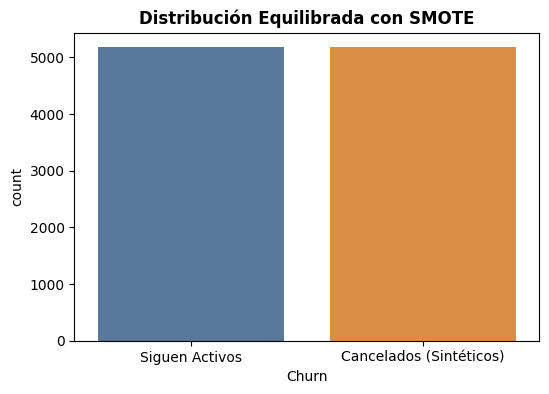

In [24]:
from imblearn.over_sampling import SMOTE

# SEPARACION X (características) Y (target)
X = df.drop('Churn', axis=1)
y = df['Churn']

# CONFIGURACION
smt = SMOTE(random_state=2)

# BALANCEO
X_res, y_res = smt.fit_resample(X, y)

# VERIFICACION
print("--- Nuevo balance de clases ---")
print(y_res.value_counts(normalize=True) * 100)

# UNION
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['Churn'] = y_res

# VISUALIZACION
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_balanced, palette=mi_paleta)
plt.title('Distribución Equilibrada con SMOTE', fontweight='bold')
plt.xticks([0, 1], ['Siguen Activos', 'Cancelados (Sintéticos)'])
plt.show()
df_balanced = pd.concat([pd.DataFrame(X_res), pd.Series(y_res, name='Churn')], axis=1)

Análisis Exploratorio Dirigido - Factores de Retención y Fuga

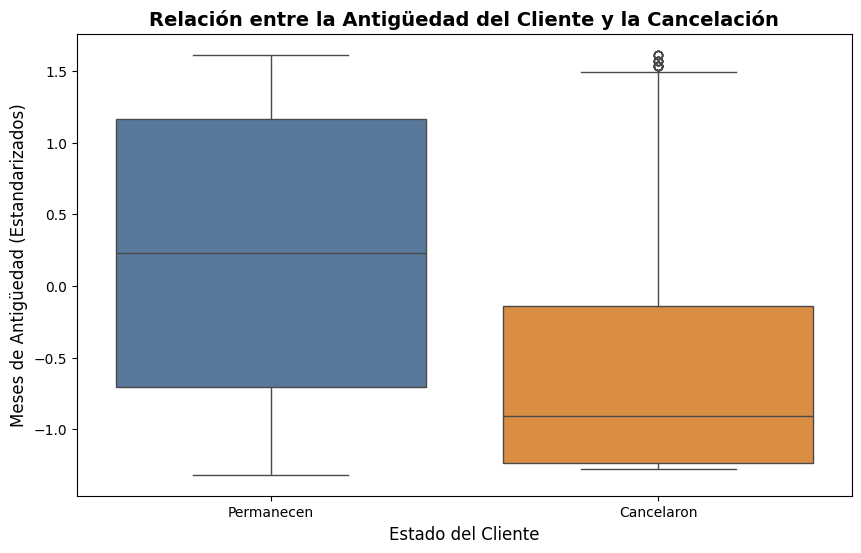

In [25]:
#TENURE VS CHURN
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Churn', y='tenure', data=df, palette=mi_paleta)

# Títulos más descriptivos
plt.title('Relación entre la Antigüedad del Cliente y la Cancelación', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Meses de Antigüedad (Estandarizados)', fontsize=12)

# Cambiamos 0 y 1 por nombres reales en el eje X
plt.xticks([0, 1], ['Permanecen', 'Cancelaron'])

plt.show()

Nota: Los valores de antigüedad se presentan estandarizados (media 0 y desviación estándar 1). Los valores negativos representan una antigüedad inferior al promedio

Tendencia: los clientes con menor tiempo de permanencia (tenure bajo) tienen una probabilidad significativamente mayor de cancelar el servicio

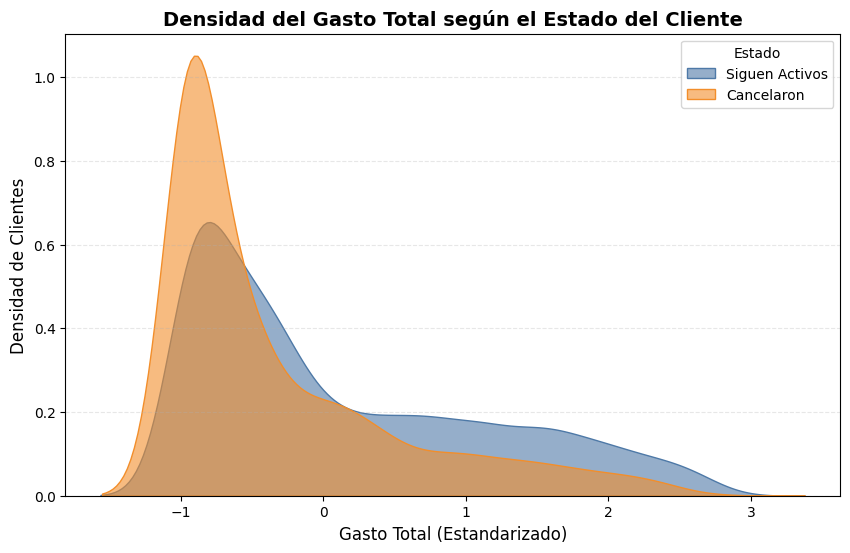

In [26]:
#GASTO TOTAL VS CHURN

plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['Churn'] == 0]['Total'], label='Siguen Activos', fill=True, color=mi_paleta[0], alpha=0.6)
sns.kdeplot(df[df['Churn'] == 1]['Total'], label='Cancelaron', fill=True, color=mi_paleta[1], alpha=0.6)

plt.title('Densidad del Gasto Total según el Estado del Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Total (Estandarizado)', fontsize=12)
plt.ylabel('Densidad de Clientes', fontsize=12)
plt.legend(title='Estado')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

El gráfico de densidad muestra que la mayor concentración de cancelaciones ocurre en clientes con un Gasto Total bajo. Esto sugiere que la fuga de clientes es prematura: se retiran antes de generar un valor acumulado significativo para la empresa

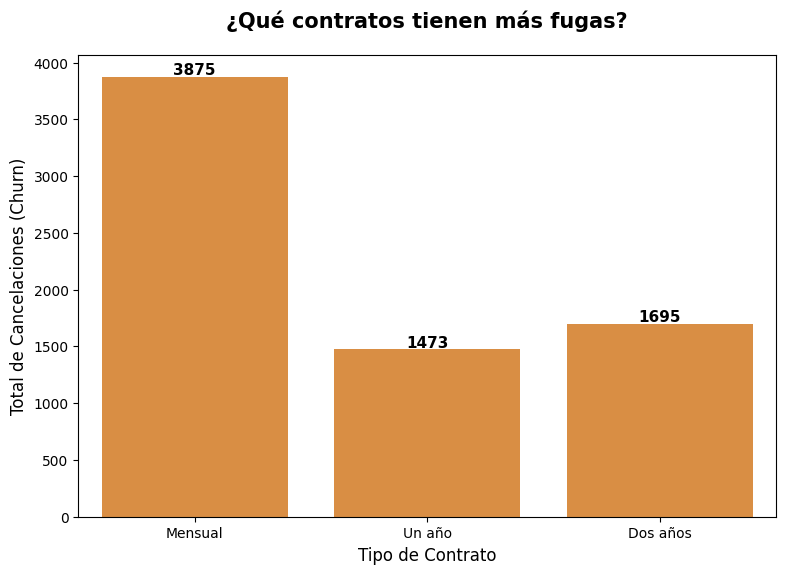

In [27]:
#CANCELACION POR TIPO DE CONTRATOS

contratos = ['Contract_month-to-month', 'Contract_one year', 'Contract_two year']
nombres_limpios = ['Mensual', 'Un año', 'Dos años']

# SUMAMOS CUANTOS CHURN=1 HAY X CONTRATO
churn_por_contrato = [df[df[c] == 1]['Churn'].count() for c in contratos]

plt.figure(figsize=(9, 6))
# VISUALIZAMOS
ax = sns.barplot(x=nombres_limpios, y=churn_por_contrato, color=mi_paleta[1])

plt.title('¿Qué contratos tienen más fugas?', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total de Cancelaciones (Churn)', fontsize=12)
plt.xlabel('Tipo de Contrato', fontsize=12)

# ETIQUETAS
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

El análisis dirigido revela que la modalidad de Contrato Mensual es el principal foco de deserción. Lo que sugiere que las estrategias de retención deben priorizar la migración de clientes a planes anuales.

Análisis de Dependencia Estadística (Correlación de Pearson)

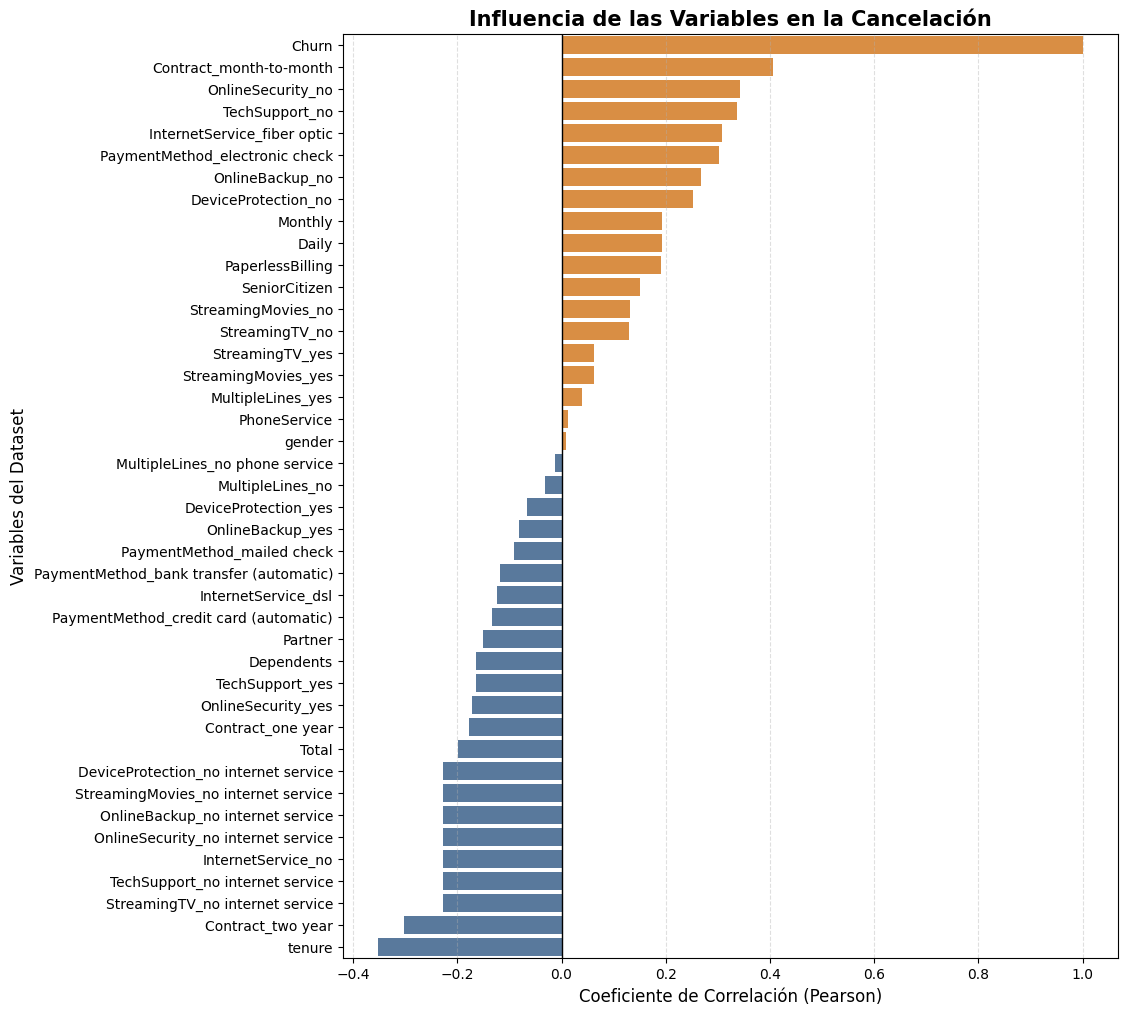

In [28]:
# CALCULO DE CORRELACION
corr_matrix = df.corr()

# EXTRAEMOS LA CORR CON CHURN
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# GRAFICO
plt.figure(figsize=(10, 12))

colores_corr = [mi_paleta[1] if x > 0 else mi_paleta[0] for x in churn_corr.values]

sns.barplot(x=churn_corr.values, y=churn_corr.index, palette=colores_corr)

plt.title('Influencia de las Variables en la Cancelación', fontsize=15, fontweight='bold')
plt.xlabel('Coeficiente de Correlación (Pearson)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea central clara
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

División del Dataset en Conjuntos de Entrenamiento y Prueba

In [29]:
from sklearn.model_selection import train_test_split

# X_res / y_res SON DATOS BALANCEADOS CON SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=123)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 7243 muestras
Prueba: 3105 muestras


Construcción y Entrenamiento de Modelos de Aprendizaje Automático

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# INICIALIZAR
rf_model = RandomForestClassifier(random_state=123)
lr_model = LogisticRegression(max_iter=1000, random_state=123)

# ENTRENAR
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

Evaluación de Modelos (Métricas)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

# PREDICCIONES (EXAMEN)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# RESULTADOS Random Forest
print("--- EVALUACIÓN: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# RESULTADOS Regresión Logística
print("\n--- EVALUACIÓN: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

--- EVALUACIÓN: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1568
           1       0.81      0.87      0.84      1537

    accuracy                           0.84      3105
   macro avg       0.84      0.84      0.84      3105
weighted avg       0.84      0.84      0.84      3105


--- EVALUACIÓN: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1568
           1       0.80      0.84      0.82      1537

    accuracy                           0.82      3105
   macro avg       0.82      0.82      0.82      3105
weighted avg       0.82      0.82      0.82      3105



Efectividad del modelo

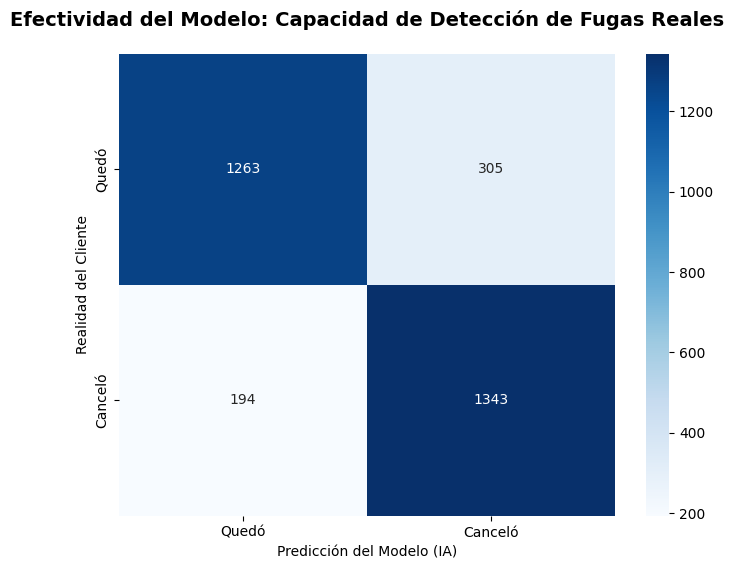

In [32]:
from sklearn.metrics import confusion_matrix

# Crear la matriz
cm = confusion_matrix(y_test, y_pred_rf)

# Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Quedó', 'Canceló'],
            yticklabels=['Quedó', 'Canceló'])

# Título enfocado en negocio
plt.title('Efectividad del Modelo: Capacidad de Detección de Fugas Reales', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicción del Modelo (IA)')
plt.ylabel('Realidad del Cliente')
plt.show()

Conclusión Estratégica

Rendimiento del Modelo: Se seleccionó el modelo Random Forest por presentar un F1-Score de 0.84 y una capacidad de detección (Recall) del 87% para los casos de cancelación.

Hallazgos Clave: El análisis de importancia de variables y el análisis dirigido confirman que la antigüedad (tenure) y el tipo de contrato mensual son los factores que más influyen en la decisión del cliente. Es decir, el problema no es el servicio en sí, sino la falta de compromiso a largo plazo y la falta de historial del cliente.

Recomendación de Negocio

Fidelizar novatos: Como se van rápido, hay que cuidarlos el primer mes.

Migrar contratos: Si logras que pasen de 'Mensual' a 'Anual' (quizás ofreciendo soporte técnico gratis), el riesgo de que se vayan cae drásticamente según vimos en la correlación.

In [33]:
# 1. Guardar el DataFrame procesado a un archivo JSON
df.to_json('TelecomX_Resultados.json', orient='records', indent=4)

# 2. Descargar el archivo a tu PC
from google.colab import files
files.download('TelecomX_Resultados.json')

print("¡Archivo 'TelecomX_Resultados.json' generado y listo para descargar!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Archivo 'TelecomX_Resultados.json' generado y listo para descargar!
